# Análisis Exploratorio: Clima y Rendimiento de Cultivos (1923-2025)

Con el dataset de clima y cultivos ya fusionado, este notebook hace la primera pregunta real del proyecto: ¿el clima histórico tuvo algo que ver con cómo rindieron los cultivos en Argentina? Lo recorremos en capas — primero cómo evolucionó cada cultivo en el tiempo, después cómo varía por provincia, y recién al final cruzamos clima con rendimiento, que es donde está la pregunta que motiva todo el proyecto.

## 1. Librerías y Carga del Dataset

### 1.1 Librerías

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

### 1.2 Carga del Dataset

In [2]:
RUTA_PROYECTO = Path().resolve()
if RUTA_PROYECTO.name == "notebook":  # los notebooks se ejecutan desde la carpeta notebook/
    RUTA_PROYECTO = RUTA_PROYECTO.parent
RUTA_PROCESSED = RUTA_PROYECTO / "data" / "processed"

df = pd.read_csv(RUTA_PROCESSED / "fusion_clima_cultivos.csv")

print(df.shape)
df.head()

(138926, 21)


,cultivo,anio,campania,provincia,provincia_id,departamento,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,...,TMAX,TMIN,TMEDIA,HELIOF,VTO_MVEL,VEL_MED,PRE_EST,HUM_REL,NUB_TOTAL,PRECIP
0,avena,1923,1923/1924,BUENOS AIRES,6.0,Adolfo Alsina,6007.0,8000.0,6700.0,6700.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,avena,1923,1923/1924,BUENOS AIRES,6.0,Adolfo Gonzales Chaves,6014.0,84000.0,78000.0,124800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,avena,1923,1923/1924,BUENOS AIRES,6.0,Alberti,6021.0,4700.0,4200.0,4494.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,avena,1923,1923/1924,BUENOS AIRES,6.0,Ayacucho,6042.0,1780.0,1553.0,1508.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,avena,1923,1923/1924,BUENOS AIRES,6.0,Azul,6049.0,10000.0,8500.0,11390.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.3 Verificación de Cardinalidad para Conversión a Category

In [3]:
candidatas = ['cultivo', 'provincia', 'campania', 'departamento']
for col in candidatas:
    print(f"{col}: {df[col].nunique()} valores únicos")

cultivo: 8 valores únicos
provincia: 23 valores únicos
campania: 418 valores únicos
departamento: 420 valores únicos


### 1.4 Corrección de la Columna `campania`

**Hallazgo:** al verificar la cardinalidad de `campania` para una posible conversión a `category`, se detectaron 418 valores únicos en lugar de los ~103 esperados (uno por año). La investigación reveló 549 filas (0,4% del dataset) con inconsistencias, concentradas exclusivamente en el cultivo `avena`:

- **Año 1929 (235 filas):** `campania` registrado como `1928/1930` en lugar de `1929/1930`.
- **Año 1950 (314 filas):** `campania` con un valor distinto e incremental en cada fila (`1950/1952`, `1950/2007`, `1950/1969`...), consistente con un error de autocompletado en la planilla de origen.

La columna `anio` está correcta en ambos casos — el error afecta solo al campo descriptivo `campania`, por lo que **no invalida la fusión con clima ya realizada** (basada en `anio`). Dado que `campania` es 100% derivable de `anio` (patrón `anio/anio+1` sin excepciones en el resto del dataset), se corrige recalculándola por completo en lugar de parchear registro por registro.

In [4]:
df['campania'] = df['anio'].astype(str) + '/' + (df['anio'] + 1).astype(str)

print("Valores únicos de campania:", df['campania'].nunique())
print("Valores únicos de anio:", df['anio'].nunique())

Valores únicos de campania: 103
Valores únicos de anio: 103


### 1.5 Conversión a Category

In [5]:
cols_categoricas = ['cultivo', 'provincia', 'campania', 'departamento']
df[cols_categoricas] = df[cols_categoricas].astype('category')

df.dtypes

cultivo                    category
anio                          int64
campania                   category
provincia                  category
provincia_id                float64
departamento               category
departamento_id             float64
superficie_sembrada_ha      float64
superficie_cosechada_ha     float64
produccion_tm               float64
rendimiento_kgxha           float64
TMAX                        float64
TMIN                        float64
TMEDIA                      float64
HELIOF                      float64
VTO_MVEL                    float64
VEL_MED                     float64
PRE_EST                     float64
HUM_REL                     float64
NUB_TOTAL                   float64
PRECIP                      float64
dtype: object

### 1.6 Funciones Auxiliares

Dos cálculos se repiten varias veces a lo largo de este notebook con exactamente la misma lógica, cambiando solo qué columnas agrupan o qué tabla graficar: el cálculo del rendimiento ponderado (Secciones 2.2, 3.2 y 3.3) y el dibujo del heatmap provincia-cultivo (Secciones 3.2 y 3.3). En vez de repetir el bloque de código cada vez, los definimos una sola vez acá.

In [6]:
def calcular_rendimiento_ponderado(df, columnas_grupo):
    """
    Agrupa por `columnas_grupo` y calcula el rendimiento ponderado (producción total x 1000 /
    superficie cosechada total) en vez de un promedio simple del rendimiento por fila, para que
    las observaciones con mayor superficie pesen más — como corresponde agronómicamente.
    """
    resultado = df.groupby(columnas_grupo, observed=True).agg(
        produccion_total_tm=('produccion_tm', 'sum'),
        superficie_cosechada_total_ha=('superficie_cosechada_ha', 'sum')
    ).reset_index()

    resultado['rendimiento_ponderado_kgxha'] = (
        resultado['produccion_total_tm'] * 1000 / resultado['superficie_cosechada_total_ha']
    )
    return resultado


def graficar_heatmap_rendimiento(tabla_pivot, titulo):
    """
    Dibuja el heatmap de rendimiento ponderado por provincia y cultivo a partir de una tabla ya
    pivoteada. Reutilizado por la serie histórica completa y la ventana reciente (2010-2025): el
    código de graficado es idéntico en ambos casos, solo cambian la tabla de entrada y el título.
    """
    fig, ax = plt.subplots(figsize=(10, 12))

    datos_enmascarados = np.ma.masked_invalid(tabla_pivot.values)

    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color='lightgray')

    im = ax.imshow(datos_enmascarados, cmap=cmap, aspect='auto')

    ax.set_xticks(range(len(tabla_pivot.columns)))
    ax.set_xticklabels(tabla_pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(tabla_pivot.index)))
    ax.set_yticklabels(tabla_pivot.index)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Rendimiento ponderado (kg/ha)')

    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

## 2. Exploración Univariada por Cultivo

### 2.1 Cobertura Temporal por Cultivo

In [7]:
cobertura = df.groupby('cultivo').agg(
    anio_min=('anio', 'min'),
    anio_max=('anio', 'max'),
    anios_con_datos=('anio', 'nunique'),
    cantidad_registros=('anio', 'count')
)

cobertura

,anio_min,anio_max,anios_con_datos,cantidad_registros
cultivo,,,,
avena,1923,2025,103,24444
centeno,1923,2025,103,15095
girasol,1969,2024,56,10647
maní,1927,2024,98,5257
maíz,1923,2024,102,33515
soja,1941,2024,84,12602
sorgo,1969,2024,56,12135
trigo,1927,2025,99,25231


### 2.2 Rendimiento Ponderado Nacional por Cultivo y Año

In [8]:
rendimiento_nacional = calcular_rendimiento_ponderado(df, ['cultivo', 'anio'])
rendimiento_nacional.head(10)

,cultivo,anio,produccion_total_tm,superficie_cosechada_total_ha,rendimiento_ponderado_kgxha
0,avena,1923,1104052.0,859596.0,1284.384757
1,avena,1924,775611.0,690902.0,1122.606390
2,avena,1925,1166682.0,905407.0,1288.571880
3,avena,1926,961998.0,898068.0,1071.186146
4,avena,1927,759000.0,705430.0,1075.939498
5,avena,1928,945974.0,887429.0,1065.971475
6,avena,1929,988952.0,872415.0,1133.579776
7,avena,1930,885175.0,907910.0,974.958972
8,avena,1931,1059314.0,825830.0,1282.726469
9,avena,1932,994300.0,881610.0,1127.822960


### 2.3 Evolución del Rendimiento Ponderado por Cultivo

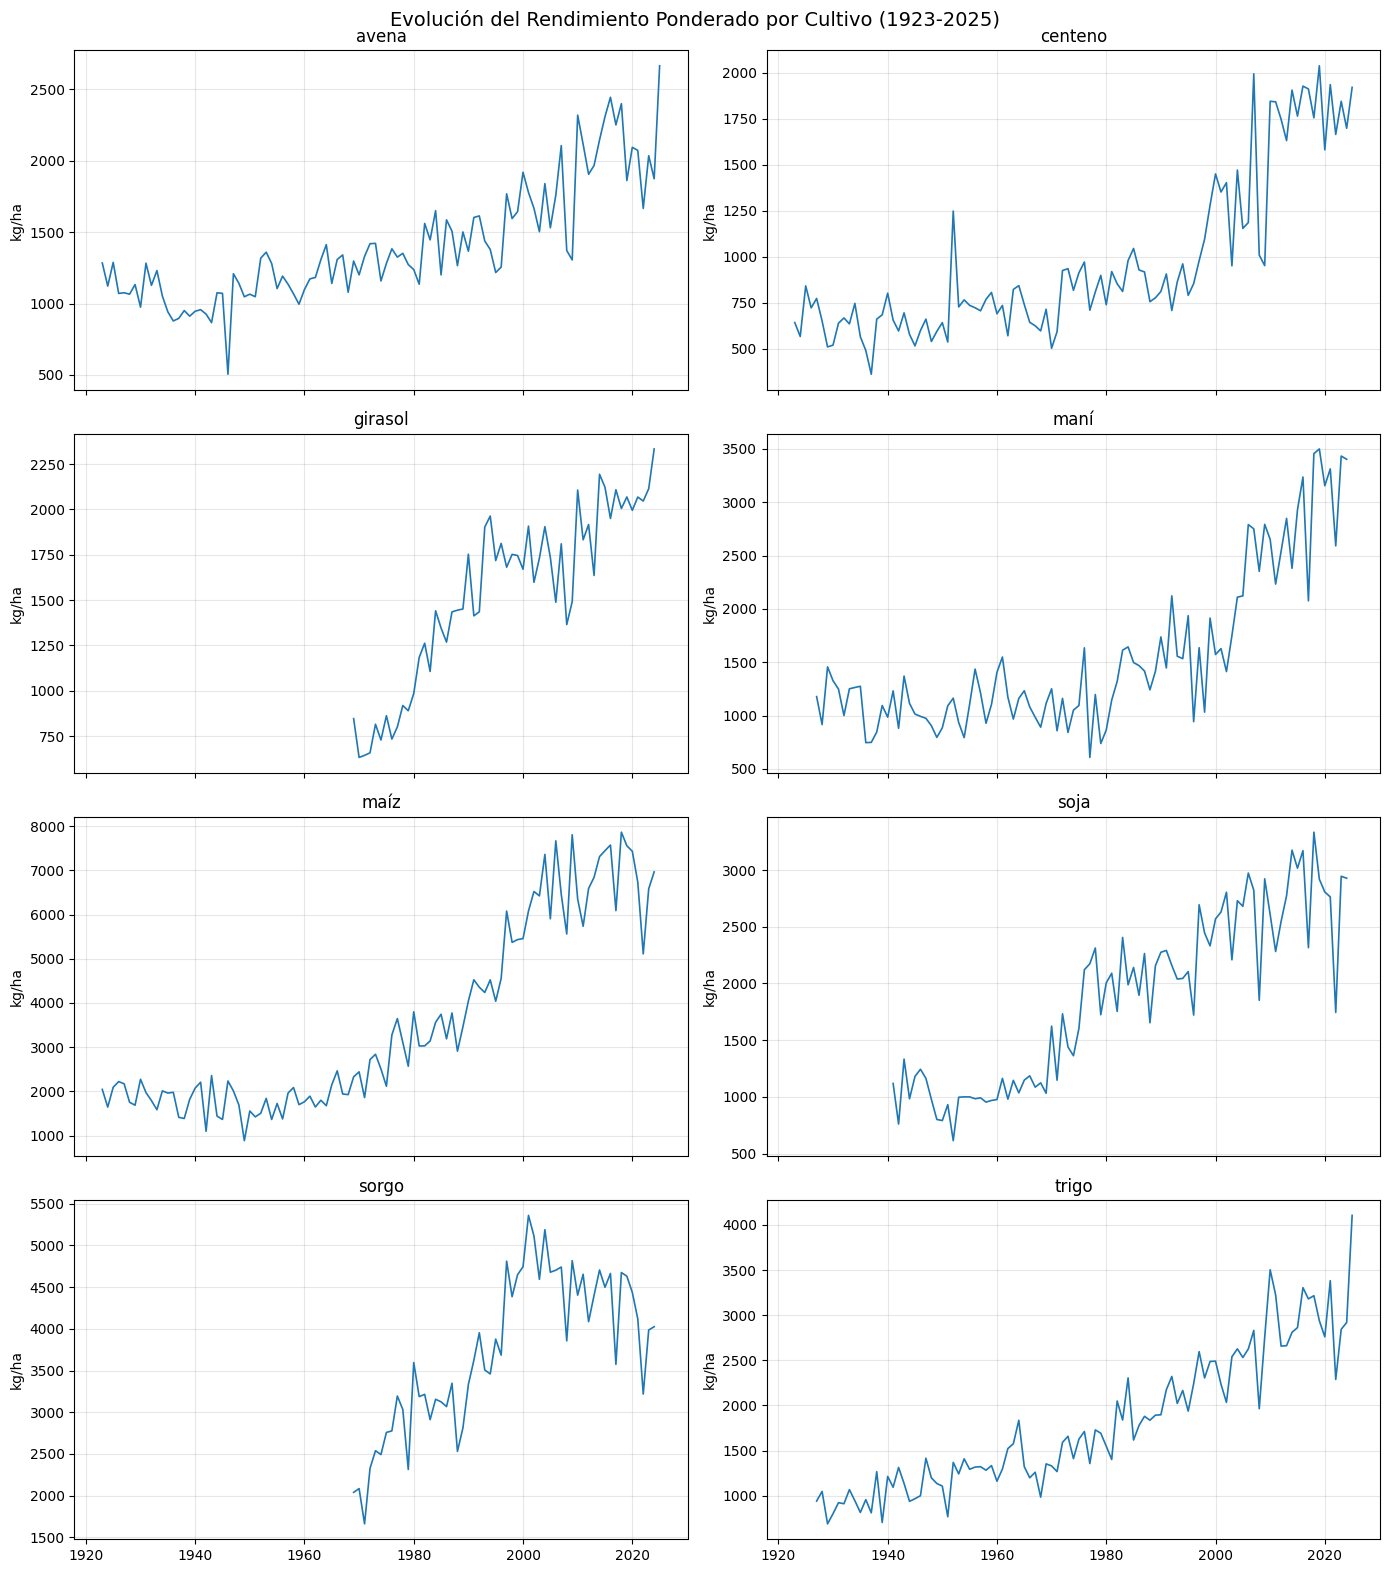

In [9]:
cultivos = rendimiento_nacional['cultivo'].unique()

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

for ax, cultivo in zip(axes, cultivos):
    datos_cultivo = rendimiento_nacional[rendimiento_nacional['cultivo'] == cultivo]
    ax.plot(datos_cultivo['anio'], datos_cultivo['rendimiento_ponderado_kgxha'], linewidth=1.2, color='tab:blue')
    ax.set_title(cultivo)
    ax.set_ylabel('kg/ha')
    ax.grid(alpha=0.3)

fig.suptitle('Evolución del Rendimiento Ponderado por Cultivo (1923-2025)', fontsize=14)
plt.tight_layout()
plt.show()

**Conclusión — Evolución del rendimiento ponderado por cultivo (1923-2025)**

Los 8 cultivos muestran una tendencia ascendente sostenida en su rendimiento por hectárea, con una aceleración particularmente marcada desde la década de 1990 (un período en el que se difundieron nuevas tecnologías de cultivo en Argentina; esta atribución es una hipótesis que los datos de este proyecto no permiten verificar). Esta aceleración es más pronunciada en soja, maíz, sorgo y maní, y se acompaña de mayor volatilidad interanual en el período reciente. Se identificaron dos quiebres puntuales de interés histórico: una caída abrupta en avena hacia mediados de la década de 1940 (coincidente con la Segunda Guerra Mundial, hipótesis a confirmar con fuentes externas) y un pico aislado en centeno en 1952, explicado por un buen año generalizado en Buenos Aires, Córdoba y La Pampa (verificado por desagregación provincial). Ninguno de estos dos eventos puede contrastarse con variables climáticas propias, dado que la cobertura de clima del proyecto comienza en 1991.

## 3. Exploración por Provincia

### 3.1 Cobertura de Cultivos por Provincia

In [10]:
cobertura_provincia = df.groupby('provincia', observed=True)['cultivo'].nunique().sort_values(ascending=False)
cobertura_provincia

provincia
BUENOS AIRES           8
CATAMARCA              8
CHACO                  8
CORRIENTES             8
CÓRDOBA                8
ENTRE RÍOS             8
FORMOSA                8
TUCUMÁN                8
JUJUY                  8
LA PAMPA               8
MENDOZA                8
MISIONES               8
SANTIAGO DEL ESTERO    8
SAN LUIS               8
SALTA                  8
SANTA FE               8
LA RIOJA               6
CHUBUT                 5
RÍO NEGRO              5
SAN JUAN               5
NEUQUÉN                4
SANTA CRUZ             4
TIERRA DEL FUEGO       3
Name: cultivo, dtype: int64

### 3.2 Heatmap de Rendimiento — Serie Histórica Completa (1923-2025)

In [11]:
rendimiento_provincia_cultivo = calcular_rendimiento_ponderado(df, ['provincia', 'cultivo'])

tabla_pivot = rendimiento_provincia_cultivo.pivot(index='provincia', columns='cultivo', values='rendimiento_ponderado_kgxha')
tabla_pivot

cultivo,avena,centeno,girasol,maní,maíz,soja,sorgo,trigo
provincia,,,,,,,,
BUENOS AIRES,1344.810254,855.652818,1633.357315,3373.706383,4177.788721,2637.252282,3687.385888,1915.520064
CATAMARCA,774.644809,860.890302,2539.285714,1502.800573,3545.397812,2469.495645,2607.224838,1456.283144
CHACO,740.384615,715.962441,1437.318219,927.252294,2820.940802,1954.815860,2669.481549,1462.857785
CHUBUT,1058.590447,804.324156,NaN,NaN,995.578016,NaN,918.367347,979.958827
CORRIENTES,766.840754,599.625234,1071.447047,887.927954,1206.510351,1595.885355,2418.700479,1895.464143
CÓRDOBA,1194.136689,806.633640,1510.240381,1697.746598,4542.232650,2653.323765,3556.288839,1573.382394
ENTRE RÍOS,825.949518,681.399210,1516.650581,1065.256448,3108.883143,2315.401582,3496.060262,1894.675859
FORMOSA,820.512821,666.666667,1147.377538,1243.279492,2435.850302,2013.099282,2647.085440,1437.486674
JUJUY,996.956713,751.280592,842.105263,1217.079360,2283.937644,2348.633415,3006.451960,1559.083526


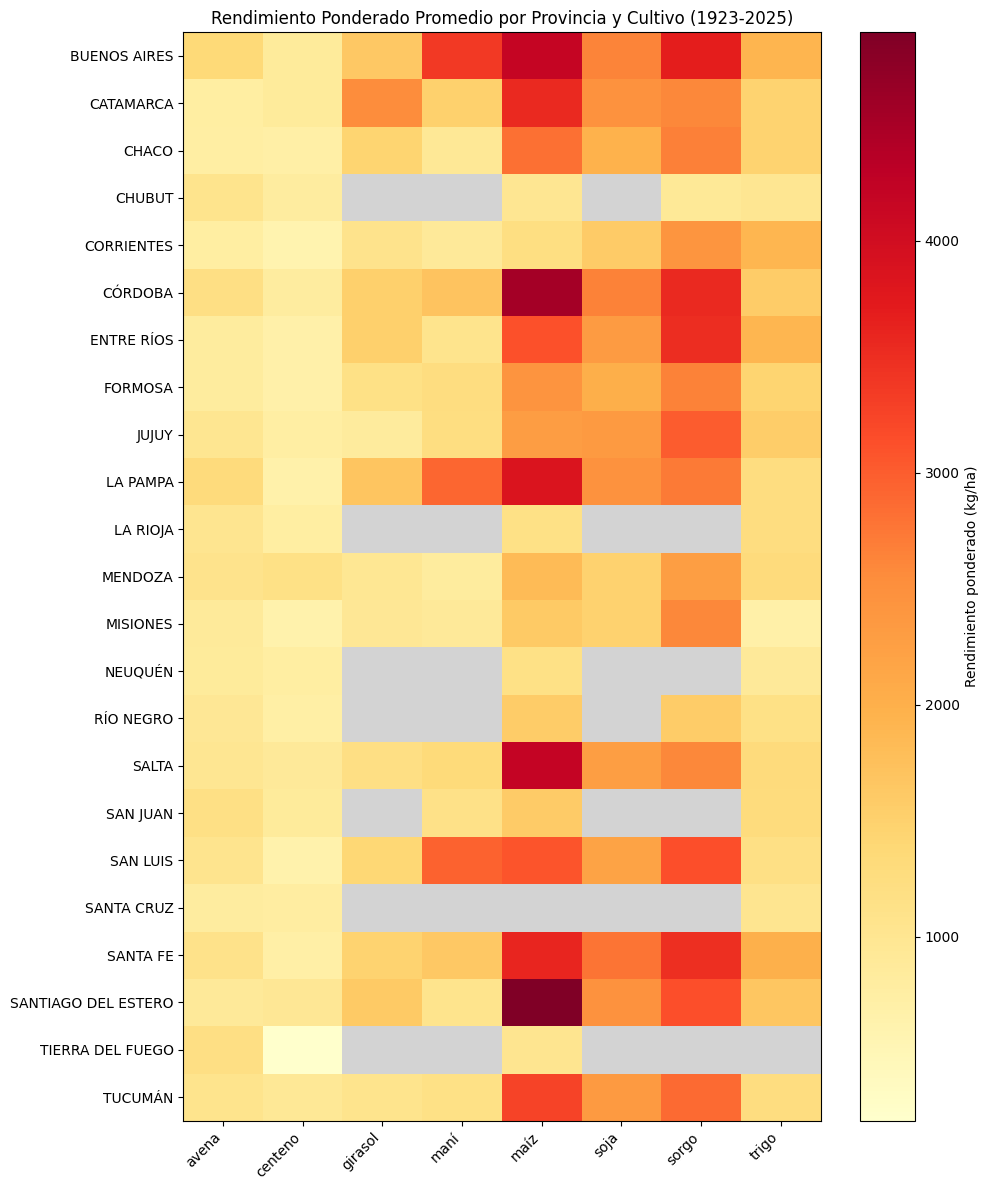

In [12]:
graficar_heatmap_rendimiento(
    tabla_pivot,
    'Rendimiento Ponderado Promedio por Provincia y Cultivo (1923-2025)'
)

### 3.3 Heatmap de Rendimiento — Últimos 15 Años (2010-2025)

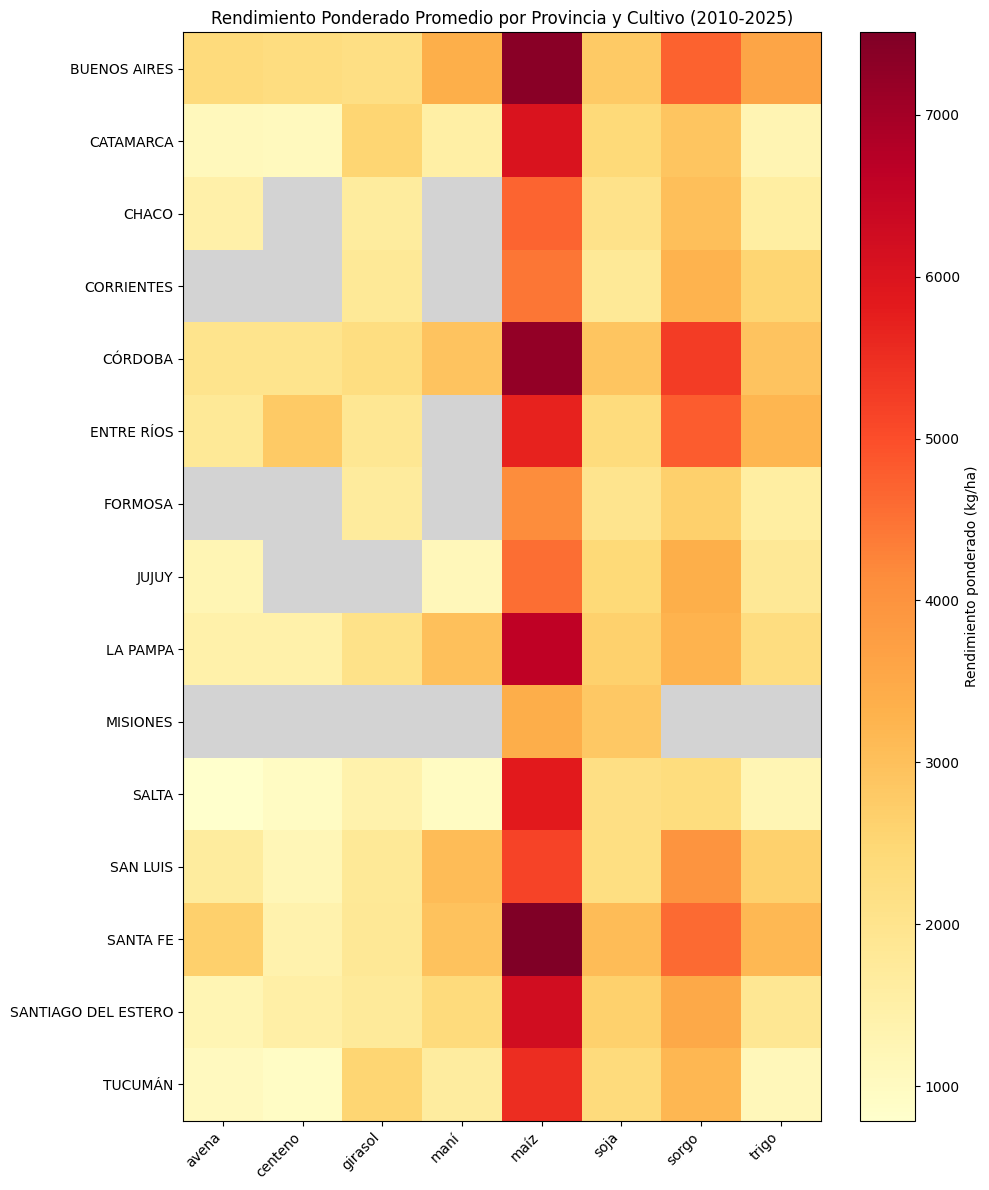

In [13]:
df_reciente = df[df['anio'] >= 2010]

rendimiento_reciente = calcular_rendimiento_ponderado(df_reciente, ['provincia', 'cultivo'])
tabla_pivot_reciente = rendimiento_reciente.pivot(index='provincia', columns='cultivo', values='rendimiento_ponderado_kgxha')

graficar_heatmap_rendimiento(
    tabla_pivot_reciente,
    'Rendimiento Ponderado Promedio por Provincia y Cultivo (2010-2025)'
)

**Conclusión — Rendimiento por Provincia y Cultivo**

La cobertura de cultivos por provincia confirma la geografía productiva conocida de Argentina: las 16 provincias de la zona núcleo y periferias productivas (Buenos Aires, Córdoba, Santa Fe, entre otras) registran los 8 cultivos, mientras que las provincias patagónicas y cuyanas más áridas (Neuquén, Santa Cruz, Tierra del Fuego) tienen una oferta mucho más acotada — coherente con sus condiciones agroecológicas.

El cruce provincia-cultivo confirma una jerarquía consistente de rendimiento: maíz y sorgo lideran en casi todas las provincias (3.000-4.900 kg/ha), seguidos por soja (1.500-2.800 kg/ha) y, en las provincias donde se cultiva, maní (hasta 3.374 kg/ha en Buenos Aires). Avena y centeno son sistemáticamente los de menor rendimiento (siempre por debajo de 1.350 kg/ha), con girasol y trigo en un nivel intermedio.

**Hallazgo metodológico importante:** el heatmap de la serie histórica completa (1923-2025) mostró a Santiago del Estero como la provincia de mayor rendimiento en maíz, por encima de Córdoba — pero esto resultó ser un artefacto de concentración temporal: el 90,6% de la producción histórica de maíz de Santiago del Estero ocurrió después de 2000, mientras que en Córdoba esa proporción es del 70,5%. Al acotar el análisis a 2010-2025, Córdoba supera a Santiago del Estero, confirmando que es el promedio histórico completo el que distorsiona la comparación entre provincias con historias de producción de distinta concentración temporal, no una diferencia de rendimiento actual real. Esto refuerza la importancia de complementar cualquier promedio de largo plazo con una ventana reciente antes de sacar conclusiones comparativas entre regiones.

## 4. Relación entre Clima y Rendimiento

### 4.1 Acotación al Período con Cobertura Climática

In [14]:
df_clima_rend = df[df['anio'] >= 1991].copy()

print("Filas totales:", df.shape[0])
print("Filas con cobertura climática (1991 en adelante):", df_clima_rend.shape[0])

Filas totales: 138926
Filas con cobertura climática (1991 en adelante): 47358


### 4.2 Correlación Clima-Rendimiento (Todos los Cultivos Agrupados)

In [15]:
variables_climaticas = ['TMAX', 'TMIN', 'TMEDIA', 'HELIOF', 'PRE_EST', 'PRECIP']

correlacion_agrupada = df_clima_rend[['rendimiento_kgxha'] + variables_climaticas].corr()['rendimiento_kgxha']
correlacion_agrupada

rendimiento_kgxha    1.000000
TMAX                -0.136422
TMIN                -0.113188
TMEDIA              -0.119883
HELIOF               0.011616
PRE_EST              0.060425
PRECIP              -0.000707
Name: rendimiento_kgxha, dtype: float64

**Conclusión — Correlación Agrupada (Línea de Base)**

Con los 8 cultivos agrupados, ninguna variable climática muestra una correlación fuerte con el rendimiento: todos los valores están por debajo de 0,14 en valor absoluto. `TMAX`, `TMIN` y `TMEDIA` tienen correlaciones negativas débiles (entre −0,11 y −0,14), mientras que `PRECIP`, `HELIOF` y `PRE_EST` son prácticamente nulas (|r| ≤ 0,06). Esta tabla se toma como línea de base: la hipótesis de trabajo es que estas relaciones débiles surgen de mezclar cultivos con respuestas climáticas distintas, no de una ausencia de relación. Se contrasta a continuación con el análisis por cultivo.

### 4.3 Correlación Clima-Rendimiento por Cultivo

In [16]:
correlacion_por_cultivo = df_clima_rend.groupby('cultivo', observed=True).apply(
    lambda g: g[variables_climaticas].corrwith(g['rendimiento_kgxha'])
)

correlacion_por_cultivo

,TMAX,TMIN,TMEDIA,HELIOF,PRE_EST,PRECIP
cultivo,,,,,,
avena,-0.482790,-0.407779,-0.434016,-0.124991,0.279227,0.122241
centeno,-0.278263,-0.245564,-0.247742,-0.119140,0.229713,0.189610
girasol,-0.308710,-0.302822,-0.303914,0.015817,0.046728,-0.064656
maní,-0.389266,-0.514968,-0.479180,0.075100,0.353360,-0.287923
maíz,-0.362049,-0.404631,-0.395579,0.027884,0.129273,-0.271672
soja,-0.128521,-0.123139,-0.128297,-0.004193,-0.007697,-0.015529
sorgo,-0.315806,-0.273485,-0.299752,0.117036,0.083566,-0.007967
trigo,-0.548261,-0.484189,-0.494567,0.069770,0.290094,0.071360


**Conclusión — Correlación Clima-Rendimiento por Cultivo**

Separar por cultivo cambia el panorama para la temperatura, pero no para la precipitación:

- **Temperatura:** los 8 cultivos muestran correlación negativa con `TMAX` (entre −0,13 y −0,55): donde y cuando hace más calor, el rendimiento es menor. Trigo (−0,55) y avena (−0,48) son los más fuertes; soja (−0,13) es la más débil.
- **Precipitación:** no hay un patrón común. Es levemente positiva en avena (0,12), centeno (0,19) y trigo (0,07), negativa en maní (−0,29) y maíz (−0,27), y prácticamente nula en girasol, soja y sorgo.

**Corrección respecto de una versión anterior.** En una primera versión, `PRECIP` mostraba correlación positiva en todos los cultivos (hasta 0,55 en trigo). Era un artefacto de un error en el notebook `03`, que sumaba las estaciones de cada provincia en lugar de promediarlas, y se corrigió. La sección 4.7 muestra qué queda de la relación una vez controlada la geografía.

**Advertencias de interpretación:** son correlaciones simples (Pearson), no relaciones causales. Mezclan diferencias entre provincias (cada cultivo se concentra en zonas distintas, con suelos y manejos distintos) y entre épocas (el rendimiento sube con la tecnología), además del efecto del clima de cada año. Por eso las diferencias entre cultivos de esta tabla no deben leerse como "sensibilidad climática" de cada uno.

### 4.4 Visualización: Precipitación vs. Rendimiento — Trigo

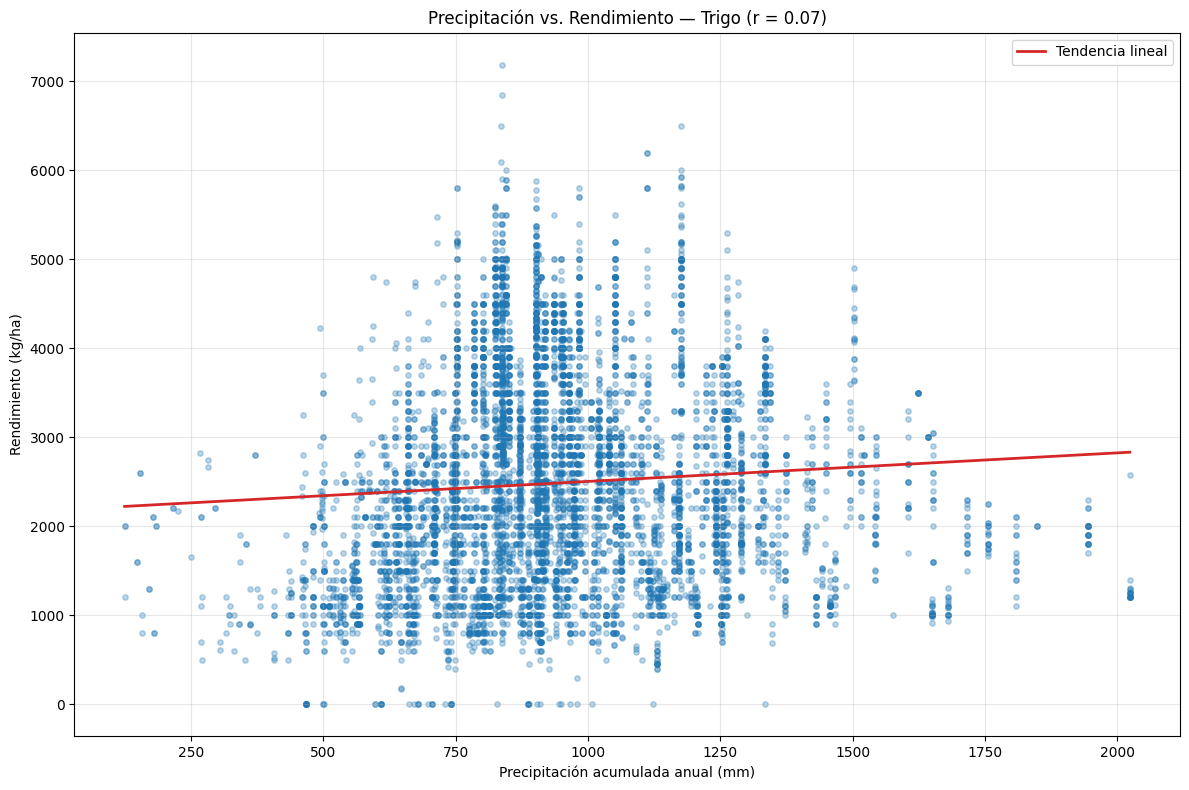

In [17]:
datos_trigo = df_clima_rend[df_clima_rend['cultivo'] == 'trigo'].dropna(subset=['PRECIP', 'rendimiento_kgxha'])

plt.figure(figsize=(12, 8))
plt.scatter(datos_trigo['PRECIP'], datos_trigo['rendimiento_kgxha'], alpha=0.3, s=15, color='tab:blue')

coeficientes = np.polyfit(datos_trigo['PRECIP'], datos_trigo['rendimiento_kgxha'], 1)
linea_tendencia = np.poly1d(coeficientes)
x_linea = np.linspace(datos_trigo['PRECIP'].min(), datos_trigo['PRECIP'].max(), 100)
plt.plot(x_linea, linea_tendencia(x_linea), color='tab:red', linewidth=2, label='Tendencia lineal')

r = datos_trigo['PRECIP'].corr(datos_trigo['rendimiento_kgxha'])
plt.title(f'Precipitación vs. Rendimiento — Trigo (r = {r:.2f})')
plt.xlabel('Precipitación acumulada anual (mm)')
plt.ylabel('Rendimiento (kg/ha)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Visualización: Temperatura Máxima vs. Rendimiento — Trigo

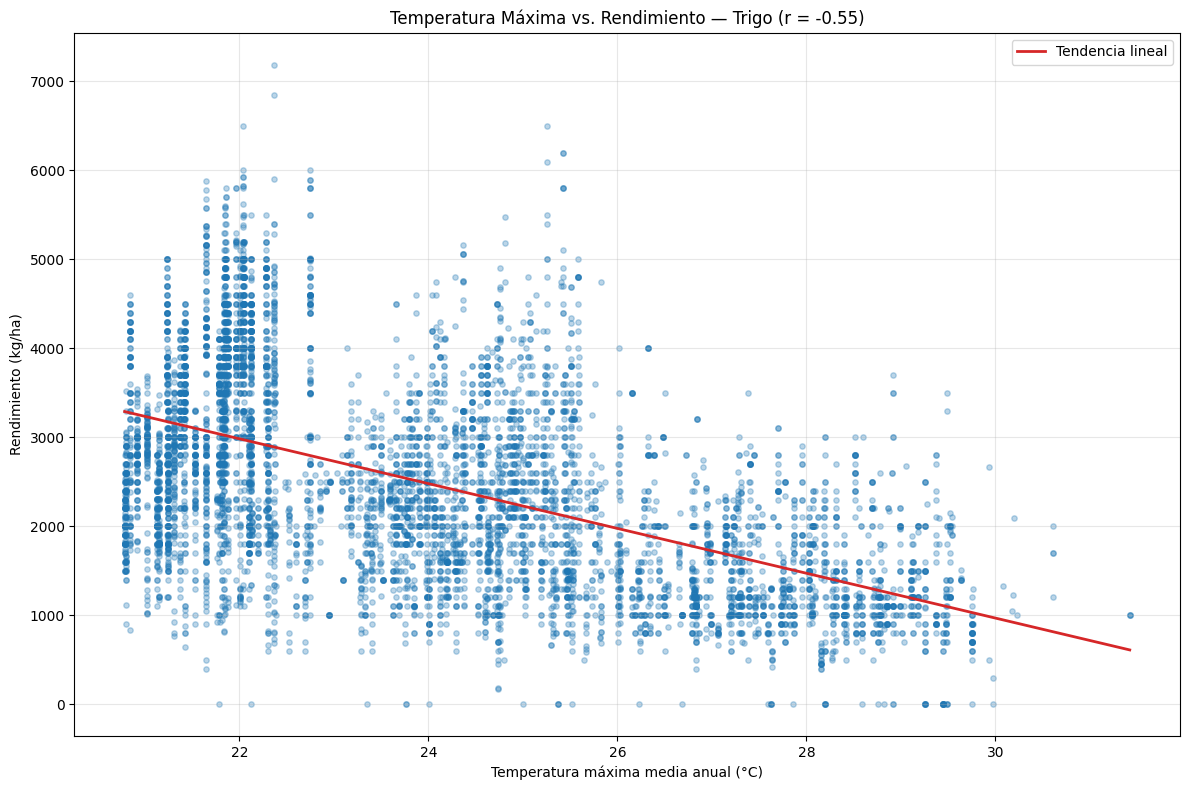

In [18]:
plt.figure(figsize=(12, 8))
plt.scatter(datos_trigo['TMAX'], datos_trigo['rendimiento_kgxha'], alpha=0.3, s=15, color='tab:blue')

coeficientes_tmax = np.polyfit(datos_trigo['TMAX'], datos_trigo['rendimiento_kgxha'], 1)
linea_tendencia_tmax = np.poly1d(coeficientes_tmax)
x_linea_tmax = np.linspace(datos_trigo['TMAX'].min(), datos_trigo['TMAX'].max(), 100)
plt.plot(x_linea_tmax, linea_tendencia_tmax(x_linea_tmax), color='tab:red', linewidth=2, label='Tendencia lineal')

r_tmax = datos_trigo['TMAX'].corr(datos_trigo['rendimiento_kgxha'])
plt.title(f'Temperatura Máxima vs. Rendimiento — Trigo (r = {r_tmax:.2f})')
plt.xlabel('Temperatura máxima media anual (°C)')
plt.ylabel('Rendimiento (kg/ha)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusión — Relación Clima-Rendimiento**

El gráfico de trigo (el cultivo con la correlación más alta con temperatura) ilustra tres aspectos para interpretar estos resultados con cuidado:

- **Temperatura:** con r = −0,55 (r² ≈ 0,30), la temperatura máxima media anual acompaña alrededor del 30 % de la variación del rendimiento de trigo entre provincias y años. **Precipitación:** con r = 0,07 (r² ≈ 0,005), la precipitación anual no acompaña casi nada de esa variación en la comparación bruta.
- **Los valores de rendimiento igual a cero** (pérdida total de cosecha) aparecen en los dos gráficos. Son consistentes con eventos puntuales que los promedios y totales anuales no capturan (heladas tardías, granizo, sequías en ventanas críticas), aunque este análisis no puede confirmarlo.
- **El patrón de "columnas verticales"** es un artefacto esperado del nivel de agregación elegido: el clima se asigna por provincia y año y lo comparten todos los departamentos de esa provincia. No es un error de los datos.

La relación bruta entre temperatura y rendimiento es la más visible, pero está mezclada con la geografía y con la tecnología. La sección 4.7 la separa.

### 4.6 Multicolinealidad entre Variables Climáticas

In [19]:
matriz_correlacion_clima = df_clima_rend[variables_climaticas].corr()
matriz_correlacion_clima

,TMAX,TMIN,TMEDIA,HELIOF,PRE_EST,PRECIP
TMAX,1.000000,0.881271,0.954628,-0.001771,-0.242801,0.038249
TMIN,0.881271,1.000000,0.966323,-0.171741,-0.061248,0.410177
TMEDIA,0.954628,0.966323,1.000000,-0.091643,-0.106353,0.249566
HELIOF,-0.001771,-0.171741,-0.091643,1.000000,-0.077297,-0.249542
PRE_EST,-0.242801,-0.061248,-0.106353,-0.077297,1.000000,0.256600
PRECIP,0.038249,0.410177,0.249566,-0.249542,0.256600,1.000000


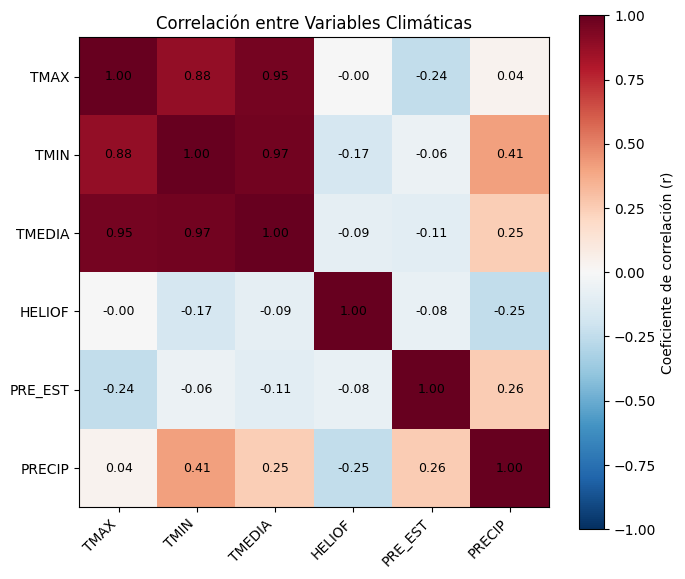

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz_correlacion_clima, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(variables_climaticas)))
ax.set_xticklabels(variables_climaticas, rotation=45, ha='right')
ax.set_yticks(range(len(variables_climaticas)))
ax.set_yticklabels(variables_climaticas)

for i in range(len(variables_climaticas)):
    for j in range(len(variables_climaticas)):
        ax.text(j, i, f'{matriz_correlacion_clima.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Coeficiente de correlación (r)')
ax.set_title('Correlación entre Variables Climáticas')
plt.tight_layout()
plt.show()

**Conclusión — Multicolinealidad entre Variables Climáticas**

`TMAX`, `TMIN` y `TMEDIA` están muy correlacionadas entre sí (r entre 0,88 y 0,97): las tres aportan esencialmente la misma información y no deberían incluirse juntas en un modelo futuro. La precipitación, en cambio, no está relacionada con `TMAX` (r = 0,04); se relaciona moderadamente con `TMIN` (0,41), consistente con que las provincias más cálidas de noche son las más húmedas. `PRE_EST` es la presión de la estación, que depende de su altitud, y debe leerse con ese cuidado. `HELIOF` es la variable más independiente de las demás (|r| ≤ 0,25).

Esta matriz se calculó con la precipitación ya corregida (ver notebook `03`). Con la versión anterior, que sumaba las estaciones de cada provincia, la correlación entre `TMAX` y `PRECIP` daba −0,80 y parecía reflejar un gradiente geográfico único; esa lectura era un artefacto del error de cálculo.

### 4.7 Control por geografía y por tendencia tecnológica

Las correlaciones de las secciones anteriores comparan filas muy distintas entre sí: provincias del norte contra la pampa húmeda, años de los noventa contra años recientes. Dos cosas se mezclan con el clima:

- **La geografía:** cada provincia tiene su clima de siempre y su nivel de rendimiento de siempre (suelo, manejo, qué parte del cultivo se siembra ahí).
- **La tecnología:** el rendimiento sube con los años por mejoras genéticas y de manejo, no por el clima.

Para aislar el efecto del clima, se compara cada provincia **consigo misma**: se resta a cada serie su tendencia lineal dentro de la provincia, de modo que lo que queda son las anomalías de cada año (un año más caluroso o más lluvioso que la tendencia de esa provincia, contra un rendimiento más alto o más bajo que su tendencia). La unidad pasa a ser cultivo-provincia-año (promedio de sus departamentos), para no contar varias veces el mismo clima provincial.

In [21]:
panel = (
    df_clima_rend.dropna(subset=['rendimiento_kgxha', 'TMAX', 'PRECIP'])
    .groupby(['cultivo', 'provincia', 'anio'], observed=True)
    .agg(rend=('rendimiento_kgxha', 'mean'), TMAX=('TMAX', 'first'), PRECIP=('PRECIP', 'first'))
    .reset_index()
)


def residuo_de_tendencia(grupo, col):
    """Resta a la serie de una provincia su tendencia lineal en el tiempo."""
    if len(grupo) < 3:
        return grupo[col] * 0
    pendiente, ordenada = np.polyfit(grupo['anio'], grupo[col], 1)
    return grupo[col] - (pendiente * grupo['anio'] + ordenada)


filas = []
for cultivo, d in panel.groupby('cultivo', observed=True):
    d = d.copy()
    for col in ['rend', 'TMAX', 'PRECIP']:
        d[col + '_dentro'] = d[col] - d.groupby('provincia', observed=True)[col].transform('mean')
        d[col + '_anom'] = d.groupby('provincia', observed=True, group_keys=False).apply(
            lambda g, c=col: residuo_de_tendencia(g, c)
        )
    filas.append({
        'cultivo': cultivo,
        'n': len(d),
        'provincias': d['provincia'].nunique(),
        'TMAX bruta': d['rend'].corr(d['TMAX']),
        'TMAX dentro de provincia': d['rend_dentro'].corr(d['TMAX_dentro']),
        'TMAX anomalías': d['rend_anom'].corr(d['TMAX_anom']),
        'PRECIP bruta': d['rend'].corr(d['PRECIP']),
        'PRECIP dentro de provincia': d['rend_dentro'].corr(d['PRECIP_dentro']),
        'PRECIP anomalías': d['rend_anom'].corr(d['PRECIP_anom']),
    })

tabla_control = pd.DataFrame(filas).set_index('cultivo').round(2)
tabla_control

,n,provincias,TMAX bruta,TMAX dentro de provincia,TMAX anomalías,PRECIP bruta,PRECIP dentro de provincia,PRECIP anomalías
cultivo,,,,,,,,
avena,284,14,-0.58,0.10,-0.35,0.27,0.18,0.29
centeno,192,11,-0.29,0.28,-0.18,0.14,0.13,0.37
girasol,330,13,-0.28,0.09,-0.32,-0.10,0.10,0.25
maní,199,12,-0.34,0.15,-0.04,-0.14,-0.05,0.05
maíz,510,15,-0.25,0.23,-0.19,-0.27,0.09,0.26
soja,498,15,-0.11,0.05,-0.21,-0.07,0.21,0.30
sorgo,416,15,-0.41,-0.17,-0.17,-0.07,0.17,0.19
trigo,456,14,-0.52,-0.13,-0.39,0.18,0.16,0.23


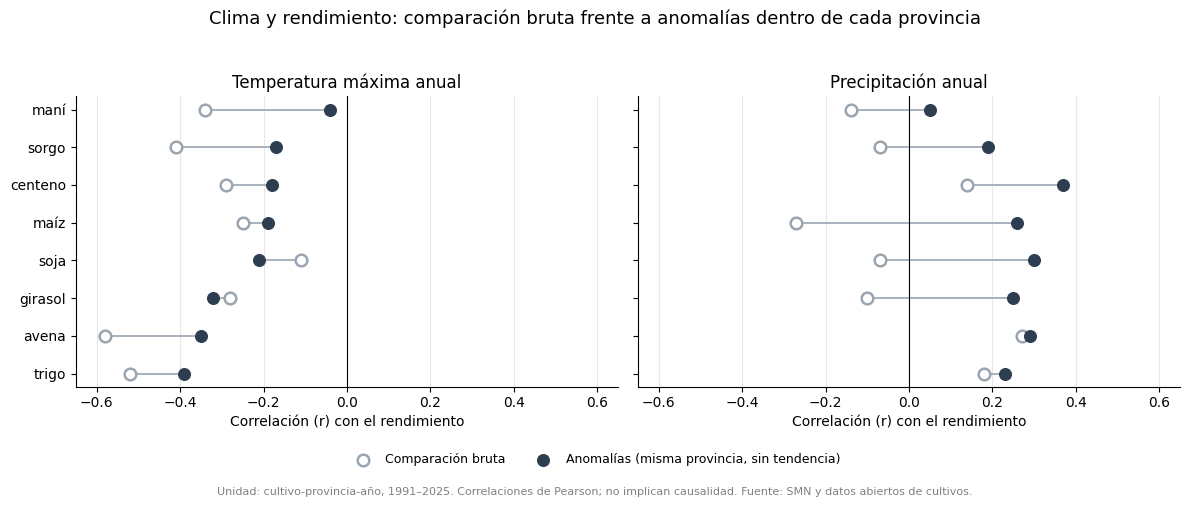

In [22]:
RUTA_IMAGENES = RUTA_PROYECTO / "images"
RUTA_IMAGENES.mkdir(parents=True, exist_ok=True)

AZUL = '#2C3E50'
GRIS = '#9AA5B1'

orden = tabla_control['TMAX anomalías'].sort_values().index  # de más negativa a menos negativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

paneles = [
    ('TMAX', 'Temperatura máxima anual'),
    ('PRECIP', 'Precipitación anual'),
]
for ax, (variable, titulo) in zip(axes, paneles):
    for y, cultivo in enumerate(orden):
        bruta = tabla_control.loc[cultivo, f'{variable} bruta']
        anomalia = tabla_control.loc[cultivo, f'{variable} anomalías']
        ax.plot([bruta, anomalia], [y, y], color=GRIS, linewidth=1.2, zorder=1)
        ax.scatter(bruta, y, s=70, facecolor='white', edgecolor=GRIS, linewidth=1.8, zorder=2,
                   label='Comparación bruta' if y == 0 else None)
        ax.scatter(anomalia, y, s=70, color=AZUL, zorder=3,
                   label='Anomalías (misma provincia, sin tendencia)' if y == 0 else None)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-0.65, 0.65)
    ax.set_yticks(range(len(orden)))
    ax.set_yticklabels(orden)
    ax.set_title(titulo)
    ax.set_xlabel('Correlación (r) con el rendimiento')
    ax.grid(axis='x', alpha=0.3)
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

handles, etiquetas = axes[0].get_legend_handles_labels()
fig.legend(handles, etiquetas, loc='lower center', ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 0.045))
fig.suptitle('Clima y rendimiento: comparación bruta frente a anomalías dentro de cada provincia', fontsize=13)
fig.text(0.5, 0.01,
         'Unidad: cultivo-provincia-año, 1991–2025. Correlaciones de Pearson; no implican causalidad. '
         'Fuente: SMN y datos abiertos de cultivos.',
         ha='center', fontsize=8, color='gray')
plt.tight_layout(rect=(0, 0.11, 1, 0.95))
fig.savefig(RUTA_IMAGENES / "analisis-clima-anomalias.png", dpi=150)
plt.show()

**Conclusión — Control por geografía y tendencia**

La columna "dentro de provincia" resta solo el nivel medio de cada provincia; "anomalías" resta además su tendencia lineal en el tiempo, que es la comparación más limpia de esta sección.

- **Precipitación:** en las anomalías, los 8 cultivos tienen correlación positiva (entre 0,05 y 0,37): los años más lluviosos que la tendencia de la provincia coinciden con rendimientos más altos que su tendencia. Los valores más altos son centeno (0,37), soja (0,30) y avena (0,29); maní (0,05) es prácticamente nulo.
- **Temperatura:** en las anomalías, los 8 cultivos tienen correlación negativa (entre −0,04 y −0,39), más marcada en trigo (−0,39), avena (−0,35) y girasol (−0,32); en maní es casi nula.
- **Soja:** era la más débil en la comparación bruta, pero en las anomalías muestra una de las respuestas más claras a la lluvia (0,30). Esto contradice la lectura inicial de que la soja es poco sensible al clima: lo que ocultaba la señal era la geografía, no la agregación anual.
- **Por qué las columnas brutas engañan:** en la comparación bruta la temperatura se asocia con rendimientos menores sobre todo porque las zonas cálidas del norte rinden menos. En "dentro de provincia" (sin quitar la tendencia) el signo de `TMAX` incluso se invierte en varios cultivos, porque tanto la temperatura como el rendimiento subieron con el tiempo.

**Límites:** son correlaciones de Pearson moderadas a débiles (|r| ≤ 0,39, es decir, a lo sumo alrededor del 15 % de la variación de las anomalías), no establecen causalidad y no tienen una prueba de significación: las provincias comparten el clima de cada año y las observaciones no son independientes. La tendencia lineal es una forma simple de separar la tecnología, y el clima se agregó por año calendario completo, no por campaña de siembra-cosecha.

## 5. Conclusiones Generales del Análisis Exploratorio

Este notebook exploró el dataset fusionado de clima y cultivos (1923-2025) en tres niveles: evolución temporal por cultivo, comportamiento geográfico por provincia, y relación entre variables climáticas y rendimiento.

**Hallazgos principales:**
- Los 8 cultivos muestran una tendencia ascendente de rendimiento, con aceleración marcada desde los años 90, y sin huecos en sus series temporales. Atribuirla a una tecnología concreta es una hipótesis que estos datos no permiten verificar.
- La geografía productiva se confirma: maíz y sorgo lideran el rendimiento en casi todas las provincias, avena y centeno son los más bajos. La comparación histórica contra la reciente mostró que los promedios de largo plazo pueden distorsionar el ranking entre provincias con historias de producción de distinta concentración temporal (caso Santiago del Estero contra Córdoba en maíz).
- **En la comparación bruta, el clima y el rendimiento se relacionan poco.** Agrupados, ninguna variable supera |r| = 0,14. Por cultivo, solo la temperatura muestra un patrón consistente (negativo, entre −0,13 y −0,55), y la precipitación no.
- **Una vez controladas la geografía y la tendencia, aparece una señal consistente pero moderada:** en los 8 cultivos, los años más lluviosos que la tendencia de la provincia coinciden con rendimientos más altos (r entre 0,05 y 0,37) y los más cálidos con rendimientos más bajos (entre −0,04 y −0,39). La relación bruta ocultaba esa señal por la mezcla de zonas y épocas.
- Las tres temperaturas son redundantes entre sí (r entre 0,88 y 0,97). La precipitación no está relacionada con `TMAX` (r = 0,04).

**Una corrección importante durante el análisis:** la precipitación provincial se calculaba sumando las estaciones de cada provincia, lo que la hacía depender del número de estaciones (Buenos Aires llegaba a ~16.000 mm anuales). Se corrigió en el notebook `03` promediando entre estaciones, y todos los resultados de este notebook se recalcularon.

**Limitaciones vigentes para cualquier análisis posterior:** cobertura climática solo desde 1991 (cultivos desde 1923); clima asignado por provincia, no por departamento; cuatro variables climáticas (`VTO_MVEL`, `VEL_MED`, `HUM_REL`, `NUB_TOTAL`) disponibles solo desde 2021; clima agregado por año calendario, no por campaña de siembra-cosecha; correlaciones simples, sin causalidad ni pruebas de significación; y la corrección de `campania`, que no afecta el análisis basado en `anio`.

Estas conclusiones son el punto de partida para la etapa siguiente: las consultas SQL y el dashboard para Power BI.

## 6. Exportación del Dataset con Correcciones de EDA

Exportamos con un nombre de archivo nuevo (`_final`), no sobrescribiendo el `fusion_clima_cultivos.csv` del notebook anterior — así queda trazable que la corrección de `campania` (Sección 1.4) se hizo en esta etapa de exploración, y no en la fusión original.

In [23]:
ruta_salida_final = RUTA_PROCESSED / "fusion_clima_cultivos_final.csv"
df.to_csv(ruta_salida_final, index=False, encoding='utf-8')

print("Archivo exportado:", ruta_salida_final)

Archivo exportado: /tmp/claude-0/work/data/processed/fusion_clima_cultivos_final.csv
